# 1-D nonstationary example: ResTGP(PP) and ResTGP(WN) against BART and the Vecchia GP

Four regions of [0, 1] with different mean behaviour and different noise levels: an
oscillation with growing amplitude (noise sd 0.8), a constant (sd 0.2), a
constant (sd 0.5), a faster and larger oscillation (sd 1.5). A stationary GP is
misspecified in both the mean and the noise; tgp adapts both at O(n^3) per leaf
per MCMC sweep.

Methods: Vecchia GP (GpGp, m = 30), BART (BayesTree), ResTGP(PP) and
ResTGP(WN) (EB started at the Vecchia MLE, default depth). 



## 1. Setup

In [ ]:
suppressPackageStartupMessages({
library(GpGp)
library(tgp)
library(BayesTree)
library(ggplot2)
library(ResTree)

})

method_order <- c("SGV", "BART", "ResTGP(PP)", "ResTGP(WN)")

SCALE <- 10                      
N_REP <- 10                    # fresh test replicates
OUT   <- sprintf("~/Documents/Projects/MSGP/ResidualTree/Sim1DExamples/output/n%d/with_bart", 320 * SCALE)
dir.create(file.path(OUT, "figures"), showWarnings = FALSE, recursive = TRUE)
theme_set(theme_bw(base_size = 12) + theme(legend.position = "bottom", legend.title = element_blank(),
                                           panel.grid.minor = element_blank()))
save_fig <- function(p, name, w, h) {
  ggsave(file.path(OUT, "figures", paste0(name, ".pdf")), p, width = w, height = h)
  #ggsave(file.path(OUT, "figures", paste0(name, ".png")), p, width = w, height = h, dpi = 200)
  p
}

## 2. Data

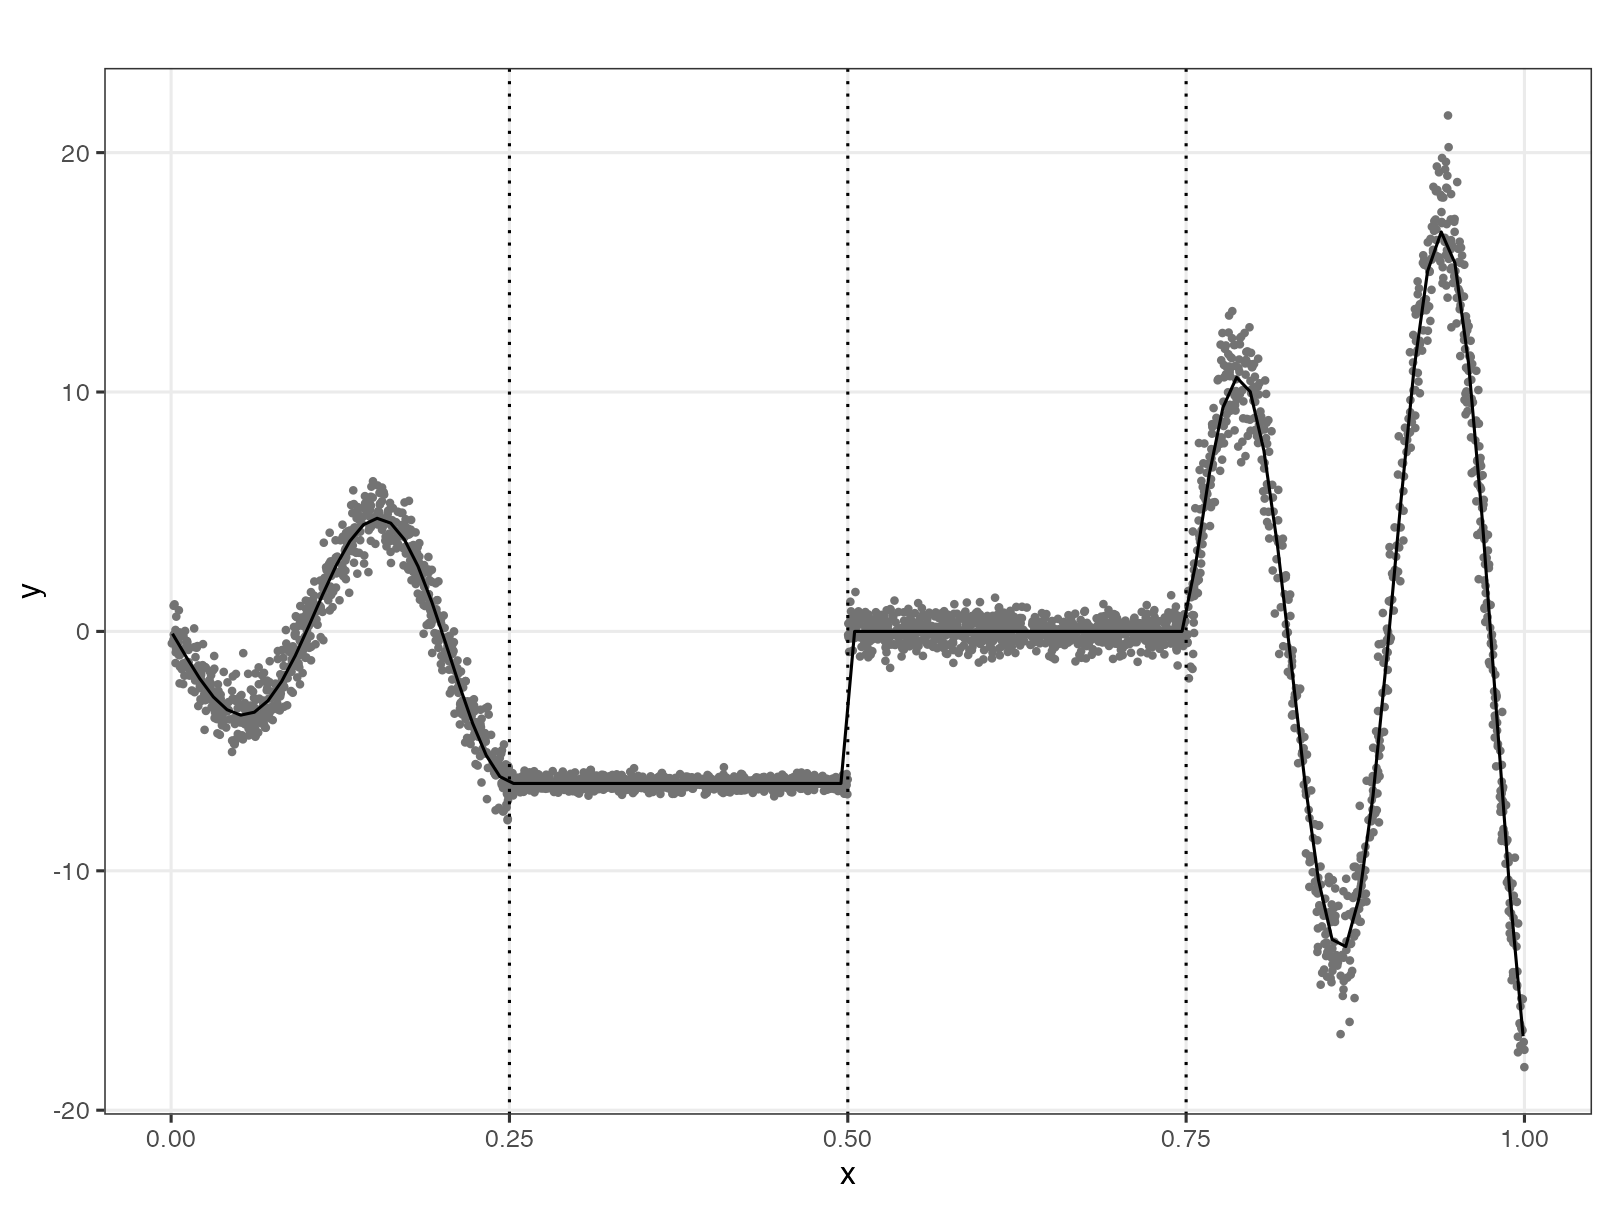

In [ ]:
f_true <- function(x) {
  y <- numeric(length(x))
  i <- x <= 0.25;           y[i] <- -3 * sin(10 * pi * x[i]) * exp(3 * x[i])
  i <- x > 0.25 & x < 0.5;  y[i] <- -3 * sin(10 * pi * 0.25) * exp(3 * 0.25)
  i <- x >= 0.5 & x < 0.75; y[i] <- sin((10 / 0.75) * pi * 0.75) * exp(3 * 0.75)
  i <- x >= 0.75;           y[i] <- sin((10 / 0.75) * pi * x[i]) * exp(3 * x[i])
  y
}
tau_true <- function(x) ifelse(x <= 0.25, 0.8, ifelse(x < 0.5, 0.2, ifelse(x < 0.75, 0.5, 1.5)))
region <- function(x) cut(x, c(0, 0.25, 0.5, 0.75, 1), c("[0,.25]", "(.25,.5)", "[.5,.75)", "[.75,1]"), include.lowest = TRUE)

set.seed(10)
x <- sort(unlist(lapply(1:4, function(i) runif(80 * SCALE, (i - 1) / 4, i / 4))))
n <- length(x)
set.seed(123)
y <- f_true(x) + tau_true(x) * rnorm(n)
X <- matrix(x, ncol = 1)

xs <- seq(0.001, 0.999, length.out = 100)
Xs <- matrix(xs, ncol = 1)
fs <- f_true(xs)
set.seed(1234)
Ynew <- fs + tau_true(xs) * matrix(rnorm(100 * N_REP), 100, N_REP)   # 100 x N_REP fresh observations

p_data <- ggplot(data.frame(x, y), aes(x, y)) + geom_point(size = 0.8, colour = "grey45") +
  geom_line(data = data.frame(x = xs, y = fs), colour = "black") +
  geom_vline(xintercept = c(0.25, 0.5, 0.75), linetype = "dotted") +
  labs(title = ""#,
      )
save_fig(p_data, "fig0_data", 9, 4.5)

## 3. Predictive Metrics

A predictive distribution is a mixture with one row per test point:
`m` (means), `s` (scales), `w` (weights), and `df` (NULL for Gaussian
components). The scores of all N_REP replicates come from the mixture CDF
evaluated once on a grid.

In [4]:
mixture <- function(m, s, w = 1, df = NULL) list(m = as.matrix(m), s = as.matrix(s), w = w, df = df)
restree_mixture <- function(pred) {
  keep <- pred$w > 0
  mixture(pred$par_mean[, keep], sqrt(pred$par_var[, keep]), pred$w[keep] / sum(pred$w[keep]),
          if (is.null(pred$par_df)) NULL else pred$par_df[, keep])
}
bart_mixture <- function(fit) {
  # BayesTree returns latent f(x) draws in rows; sigma contains the matching
  # post-burn-in noise draws, already on the original response scale.
  m <- t(fit$yhat.test)
  stopifnot(is.matrix(fit$yhat.test), ncol(m) == length(fit$sigma),
            all(is.finite(m)), all(is.finite(fit$sigma)), all(fit$sigma > 0))
  s <- matrix(rep(fit$sigma, each = nrow(m)), nrow = nrow(m))
  mixture(m, s, rep(1 / ncol(m), ncol(m)))
}
mix_cdf <- function(mx, q) {
  z <- (q - mx$m) / mx$s
  drop((if (is.null(mx$df)) pnorm(z) else pt(z, mx$df)) %*% mx$w)
}
mix_pdf <- function(mx, q) {
  z <- (q - mx$m) / mx$s
  drop(((if (is.null(mx$df)) dnorm(z) else dt(z, mx$df)) / mx$s) %*% mx$w)
}
mix_quantile <- function(mx, p) {            # bisection, all rows at once
  lo <- apply(mx$m - 10 * mx$s, 1, min); hi <- apply(mx$m + 10 * mx$s, 1, max)
  for (it in 1:60) {
    mid <- (lo + hi) / 2
    below <- mix_cdf(mx, mid) < p
    lo[below] <- mid[below]; hi[!below] <- mid[!below]
  }
  (lo + hi) / 2
}
score <- function(mx, method) {
  mu <- drop(mx$m %*% mx$w)
  lo <- mix_quantile(mx, 0.025); hi <- mix_quantile(mx, 0.975)
  sd <- (mix_quantile(mx, pnorm(1)) - mix_quantile(mx, pnorm(-1))) / 2   # half the central 68% interval
  g <- seq(min(mx$m - 10 * mx$s), max(mx$m + 10 * mx$s), length.out = 6000)
  Fg <- sapply(g, function(q) mix_cdf(mx, q))                             # 100 x 6000
  per <- do.call(rbind, lapply(1:N_REP, function(k) {
    yk <- Ynew[, k]
    data.frame(method, rep = k, region = region(xs),
               se = (yk - mu)^2,
               crps = rowSums((Fg - outer(yk, g, "<="))^2) * (g[2] - g[1]),
               logs = -log(mix_pdf(mx, yk)),
               cover = yk > lo & yk < hi, width = hi - lo, pit = mix_cdf(mx, yk))
  }))
  list(per = per, curve = data.frame(method, x = xs, mu, sd, lo, hi))
}
summarise <- function(per, by) {
  z <- aggregate(cbind(RMSE = se, CRPS = crps, logscore = logs, cover95 = cover, width95 = width) ~ ., 
  per[c("method", by, "se", "crps", "logs", "cover", "width")], mean)
  z$RMSE <- sqrt(z$RMSE)
  z
}

results <- list(); fits <- list(); seconds <- c()

## 4. Vecchia GP (GpGp, Matérn 2.5, m = 30)

In [5]:
nn = 30
t0 <- proc.time()[3]
fits$gp <- fit_model(y, X, covfun_name = "matern25_isotropic", m_seq = nn, silent = TRUE)
mu_gp <- predictions(fits$gp, Xs, X_pred = matrix(1, 100, 1), m = nn)
sd_gp <- apply(cond_sim(fits$gp, Xs, X_pred = matrix(1, 100, 1), nsims = 200, m = nn), 1, sd)
seconds["gp"] <- proc.time()[3] - t0
results$gp <- score(mixture(mu_gp, sd_gp), "SGV")
theta0 <- restree_theta(sig2 = fits$gp$covparms[1], range = fits$gp$covparms[2], nugget = fits$gp$covparms[3])
theta0

restree_theta: matern (ARD, Euclidean)
  sig2 46.686 ; range 0.018373 ; nugget 0.017866 ; nu 2.5

## 5. treeGP (tgp::btgp)

## Too expensive to compute 
```{r, eval=FALSE}
t0 <- proc.time()[3]
set.seed(1)
fits$tgp <- btgp(X, y, XX = Xs, corr="matern", bprior = "b0", pred.n = FALSE, verb = 0)
seconds["tgp"] <- proc.time()[3] - t0
results$tgp <- score(mixture(fits$tgp$ZZ.mean, sqrt(fits$tgp$ZZ.ks2)), "tgp")   # ZZ.ks2 is the full predictive variance
```


## 6. ResTGP(PP): r = 15, prior_beta = 0, EB from the Vecchia MLE

In [23]:
t0 <- proc.time()[3]
m_pp <- restree_model(X, y, r = 15, leaf_model = "PP", cut_method = "middle", prior_rho = 0.05, prior_beta = 0)
fits$pp <- restree_fit(m_pp, theta0, method = "ebayes", xnew = Xs, 
            nparticles = 1600, seed = 1, ncores=4, 
            control = list(maxit = 200))
seconds["pp"] <- proc.time()[3] - t0
results$pp <- score(restree_mixture(fits$pp$prediction), "ResTGP(PP)")
fits$pp

restree fit
  method    : ebayes 
  data      : 3200 observations, 1 inputs
  tree      : depth 8 ; r = 15 ; leaf model PP ; design maximin ; cuts middle 
  theta     : sig2 121.1 ; range 0.03688 ; nugget 0.006441 ; nu 2.5 ; matern ARD 
  sigma2_hat: 121.1 (joint EB posterior mode; identified noise variance sig2*nugget = 0.7797 )
  particles : 1600  (final ESS 1594) 
  log Z     : -4339.5096 
  loglik    : -4339.5096 
  prediction: 100 new points
  diagnostics: 1600 distinct trees; 1 resampling events; 65.5s total

## 7. ResTGP(WN): r = 15, uniform cuts, prior_beta = 0, EB from the Vecchia MLE

In [7]:
t0 <- proc.time()[3]
m_wn <- restree_model(X, y, r = 15, leaf_model = "WN", cut_method = "uniform", prior_rho = 0.05, prior_beta = 0)
fits$wn <- restree_fit(m_wn, theta0, method = "ebayes", xnew = Xs, 
            nparticles = 1600, seed = 1, ncores=2,
            control = list(maxit = 200))
seconds["wn"] <- proc.time()[3] - t0
results$wn <- score(restree_mixture(fits$wn$prediction), "ResTGP(WN)")
fits$wn

restree fit
  method    : ebayes 
  data      : 3200 observations, 1 inputs
  tree      : depth 8 ; r = 15 ; leaf model WhiteNoise ; design maximin ; cuts uniform 
  theta     : sig2 43.43 ; range 0.0246 ; nugget 0.02383 ; nu 2.5 ; matern ARD 
  sigma2_hat: 43.43 (joint EB posterior mode; identified noise variance sig2*nugget = 1.035 )
  particles : 1600  (final ESS 1599) 
  log Z     : -3321.3919 
  loglik    : -3321.3919 
  prediction: 100 new points
  diagnostics: 111 distinct trees; 6 resampling events; 4.27s total

## 8. BART (BayesTree)


In [8]:
t0 <- proc.time()[3]
set.seed(1)
fits$bart <- BayesTree::bart(
  x.train = X, y.train = y, x.test = Xs,
  ntree = 200, nskip = 1000, ndpost = 4000, keepevery = 1,
  numcut = 100, usequants = FALSE, keeptrainfits = FALSE, verbose = FALSE
)
seconds["bart"] <- proc.time()[3] - t0
results$bart <- score(bart_mixture(fits$bart), "BART")
cat(sprintf("BART: %d posterior draws; %.2f seconds fitting and prediction\n",
            nrow(fits$bart$yhat.test), seconds["bart"]))

BART: 4000 posterior draws; 181.07 seconds fitting and prediction


## 9. Scores

In [24]:
per <- do.call(rbind, lapply(results, `[[`, "per"))
curves <- do.call(rbind, lapply(results, `[[`, "curve"))
available_methods <- unique(per$method)
methods <- c(intersect(method_order, available_methods),
             setdiff(available_methods, method_order))
per$method <- factor(per$method, methods); 
curves$method <- factor(curves$method, methods)

per$all <- "all"
tab <- summarise(per, "all"); tab$all <- NULL
result_keys <- setNames(names(results), vapply(results, function(result) {
  as.character(result$curve$method[1])
}, character(1)))
row_keys <- unname(result_keys[as.character(tab$method)])
tab$seconds <- unname(seconds[row_keys])
#write.csv(tab, file.path(OUT, "scores_overall.csv"), row.names = FALSE)
print(tab, digits = 3, row.names = FALSE)


     method  RMSE  CRPS logscore cover95 width95 seconds
        SGV 0.949 0.492    1.371   0.938    3.68    1.43
       BART 1.082 0.569    1.503   0.940    4.61  181.07
 ResTGP(PP) 0.936 0.480    1.336   0.941    3.55   65.59
 ResTGP(WN) 0.989 0.458    0.953   0.947    3.06    4.28


## 10. Figures

In [10]:
save_fig <- function(p, name, w, h) {
  ggsave(file.path(OUT, "figures", paste0(name, ".pdf")), p, width = w, height = h)
  #ggsave(file.path(OUT, "figures", paste0(name, ".png")), p, width = w, height = h, dpi = 300)
  p
}

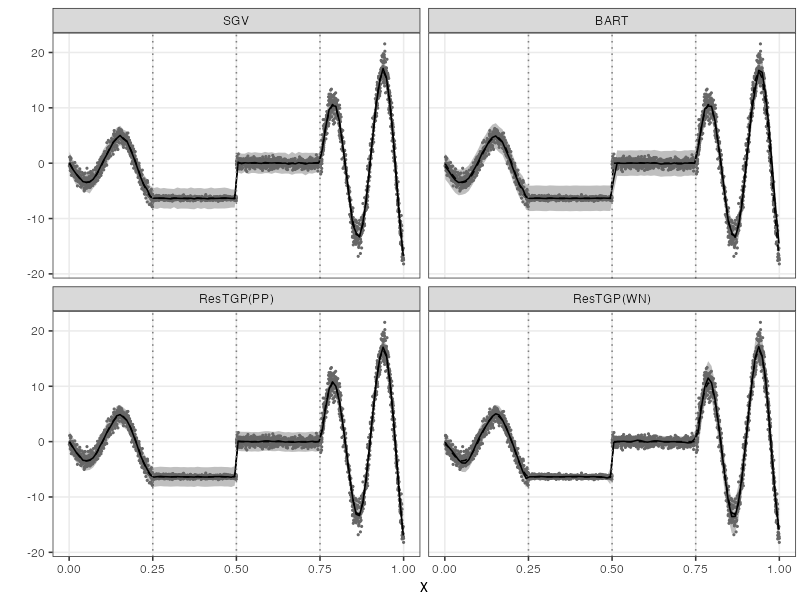

In [21]:
ltys <- setNames(c("solid", "dotdash", "dashed", "dotted", "longdash")[seq_along(methods)], methods)
shps <- setNames(c(16, 17, 15, 18, 8)[seq_along(methods)], methods)
curves$method <- factor(
  curves$method,
  levels = methods
)

p_fit <- ggplot(curves, aes(x)) +
  geom_ribbon(aes(ymin = lo, ymax = hi), fill = "grey75") +
  geom_point(data = data.frame(x, y), aes(x, y), size = 0.4, colour = "grey40") +
  geom_line(data = data.frame(x = xs, fs), aes(x, fs), linetype = "dashed") +
  geom_line(aes(y = mu)) +
  geom_vline(xintercept = c(0.25, 0.5, 0.75), linetype = "dotted", colour = "grey50") +
  facet_wrap(~ method, ncol = 2) +
  labs(title =NULL, y = "")
save_fig(p_fit, "Sim1D_fig1_predictions_n3200", 10, 6.5)
#print(p_fit)
ggsave("./output/n3200/figures/Sim1D_fig1_predictions_n3200.pdf", p_fit, width=8, height=6)

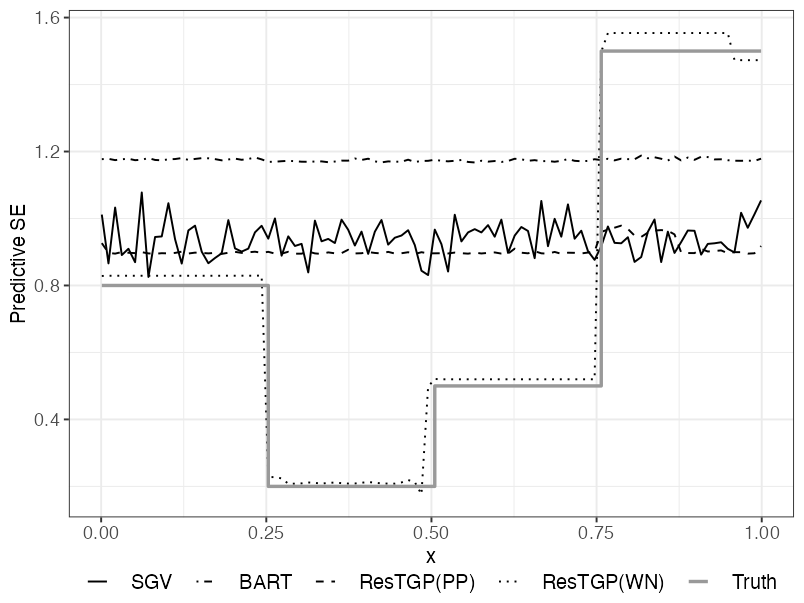

In [22]:
lv <- methods
sd_ltys <- c(ltys[lv], Truth = "solid")

curves$method <- factor(curves$method, levels = lv)
tru <- data.frame(x = xs, sd = tau_true(xs),
                  method = factor("Truth", levels = c(lv, "Truth")))

p_sd <- ggplot(curves, aes(x, sd, linetype = method)) +
  geom_line() +
  geom_step(data = tru, colour = "grey60", linewidth = 1.2) +
  scale_linetype_manual(values = sd_ltys, breaks = c(lv, "Truth")) +
  labs(title = NULL,
       subtitle = NULL,
       y = "Predictive SE") + 
  theme_bw(base_size = 15) +          
  theme(
  legend.box.spacing = unit(2, "pt"),   
  legend.margin      = margin(0, 0, 0, 0),
  legend.key.spacing = unit(16, "pt"),   
  legend.key.width   = unit(18, "pt"), 
  legend.title       = element_blank(),
  legend.position = "bottom",
    axis.title  = element_text(size = 15),
    axis.text   = element_text(size = 14),
    strip.text  = element_text(size = 14),
    legend.text  = element_text(size = 15)
  )

#print(p_sd)
save_fig(p_sd, "Sim1D_fig2_predictive_sd_n3200", 8, 4)
ggsave("./output/n3200/figures/Sim1D_fig2_predictive_sd_n3200.pdf", p_sd, width=8, height=4)

In [13]:
sessionInfo()

R version 4.4.3 (2025-02-28)
Platform: aarch64-apple-darwin20
Running under: macOS Sequoia 15.3.2

Matrix products: default
BLAS:   /System/Library/Frameworks/Accelerate.framework/Versions/A/Frameworks/vecLib.framework/Versions/A/libBLAS.dylib 
LAPACK: /Library/Frameworks/R.framework/Versions/4.4-arm64/Resources/lib/libRlapack.dylib;  LAPACK version 3.12.0

locale:
[1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8

time zone: America/Chicago
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] ResTree_0.1.9     ggplot2_4.0.2     BayesTree_0.3-1.5 tgp_2.4-23        GpGp_1.0.0       

loaded via a namespace (and not attached):
 [1] gtable_0.3.6       dplyr_1.2.0        compiler_4.4.3     renv_1.1.8         maps_3.4.3        
 [6] rpart_4.1.24       tidyselect_1.2.1   Rcpp_1.1.1         FNN_1.1.4.1        cluster_2.1.8.2   
[11] systemfonts_1.3.2  scales_1.4.0       textshap